# K-Means Clustering and Distance Metric Evaluation Across Healthcare Datasets

This notebook applies unsupervised K-Means clustering across multiple healthcare-related datasets, including diabetes, life expectancy, and SUPPORT2. The workflow includes feature preparation, feature scaling, elbow-method analysis, silhouette-score evaluation, and comparison of distance metrics.

The goal is to explore whether meaningful cluster structure appears in each dataset and to compare how different distance metrics affect silhouette scores. This notebook is included in the modeling folder because the main focus is unsupervised model development, cluster evaluation, and model-selection support rather than exploratory data analysis.


## Diabetes Dataset Clustering

This section applies K-Means clustering to the diabetes health indicators dataset after removing the target variable and scaling the input features. The elbow method and silhouette scores are used to compare possible cluster counts, followed by a distance-metric comparison for the selected cluster setting.


In [3]:
#Diabetes imputed

import pandas as pd

diabetes = pd.read_csv("diabetes_no_duplicates.csv")
print(diabetes.shape)
diabetes.head()

(229781, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [4]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Drop target for clustering
X = diabetes.drop(columns=['Diabetes_012'])

print(X.shape)
X.head()

(229781, 21)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
#standardize: feature scaling

scaler = StandardScaler()
X_scale = scaler.fit_transform(X)

print(X_scale.shape)

(229781, 21)


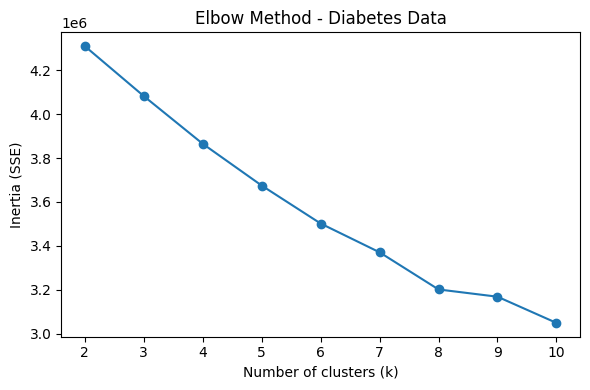

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Elbow method on scaled diabetes data
K = range(2, 11)   # k = 2 to 10
inertias = []

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scale)              # X_scale from your StandardScaler
    inertias.append(kmeans.inertia_) # SSE / within-cluster sum of squares

# Plot the elbow curve
plt.figure(figsize=(6,4))
plt.plot(K, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method - Diabetes Data")
plt.tight_layout()
plt.show()

k=2, silhouette=0.1808
k=3, silhouette=0.0673
k=4, silhouette=0.0764
k=5, silhouette=0.0860
k=6, silhouette=0.0958
k=7, silhouette=0.0931
k=8, silhouette=0.0994
k=9, silhouette=0.0934
k=10, silhouette=0.0880


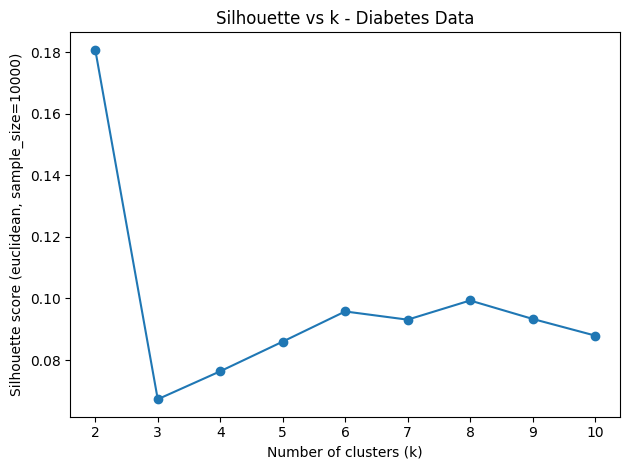

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

K = range(2, 11)
sil_scores = []

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scale)

    sil = silhouette_score(
        X_scale,
        labels,
        metric='euclidean',
        sample_size=10000,   #sample 10k points
        random_state=42
    )
    sil_scores.append(sil)
    print(f"k={k}, silhouette={sil:.4f}")

plt.figure()
plt.plot(K, sil_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score (euclidean, sample_size=10000)")
plt.title("Silhouette vs k - Diabetes Data")
plt.tight_layout()
plt.show()

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

best_k = 2 

km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = km.fit_predict(X_scale)

metrics = ['euclidean', 'manhattan', 'cosine']

for m in metrics:
    score = silhouette_score(
        X_scale,
        labels,
        metric=m,
        sample_size=10000,   # keep it fast
        random_state=42
    )
    print(f"{m}: silhouette = {score:.4f}")

euclidean: silhouette = 0.1808
manhattan: silhouette = 0.2599
cosine: silhouette = 0.1737


### Diabetes Clustering Summary

For the diabetes dataset, the clustering workflow compares inertia and silhouette scores across multiple values of k. The distance-metric comparison provides an additional check of how cluster separation changes under Euclidean, Manhattan, and cosine distance measures.


## Life Expectancy Dataset Clustering

This section applies K-Means clustering to the life expectancy dataset after removing non-numeric identifier fields and scaling the numeric features. The elbow method, silhouette scores, and distance-metric comparison are used to evaluate whether the observations form useful cluster groupings.


In [11]:
#Life Expectancy imputed
import pandas as pd

life_imputed = pd.read_csv("Life Expectancy Data - mean_mode_imputed.csv")

print(life_imputed.shape)
life_imputed.head()

(2938, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [12]:
from sklearn.preprocessing import StandardScaler

# Drop non-numeric / ID columns
X_life = life_imputed.drop(columns=['Country', 'Status'])

print(X_life.shape)   # should be (2938, something)

# Standardize
scaler_life = StandardScaler()
X_life_scale = scaler_life.fit_transform(X_life)

print(X_life_scale.shape)

(2938, 20)
(2938, 20)


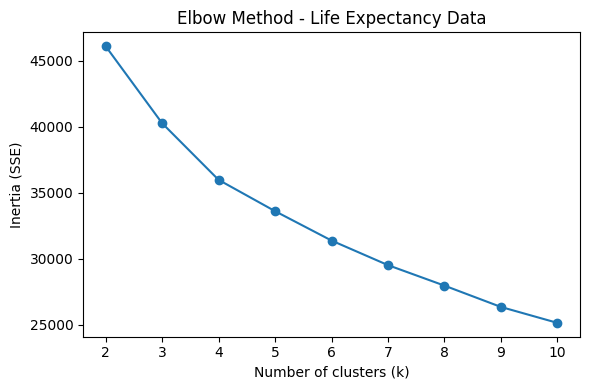

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

K = range(2, 11)
inertias_life = []

for k in K:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    km.fit(X_life_scale)             # Euclidean distance internally
    inertias_life.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertias_life, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method - Life Expectancy Data")
plt.tight_layout()
plt.show()

k=2, silhouette=0.2585
k=3, silhouette=0.2560
k=4, silhouette=0.2373
k=5, silhouette=0.1851
k=6, silhouette=0.2065
k=7, silhouette=0.2092
k=8, silhouette=0.1419
k=9, silhouette=0.1462
k=10, silhouette=0.1458


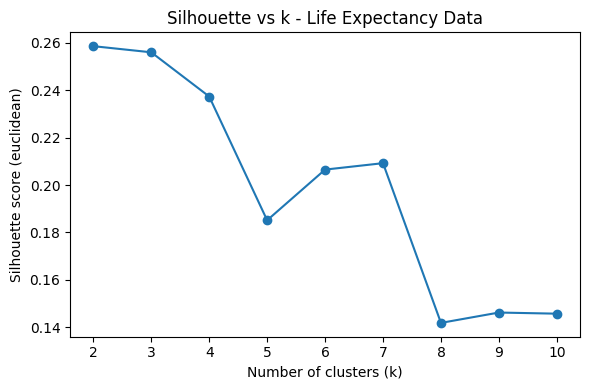

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

K = range(2, 11)
sil_scores_life = []

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_life_scale)

    sil = silhouette_score(
        X_life_scale,
        labels,
        metric='euclidean'   # default distance metric
    )
    sil_scores_life.append(sil)
    print(f"k={k}, silhouette={sil:.4f}")

plt.figure(figsize=(6,4))
plt.plot(K, sil_scores_life, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score (euclidean)")
plt.title("Silhouette vs k - Life Expectancy Data")
plt.tight_layout()
plt.show()

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

best_k_life = 2  # from silhouette vs k

km_life = KMeans(n_clusters=best_k_life, random_state=42, n_init=10)
labels_life = km_life.fit_predict(X_life_scale)

for m in ['euclidean', 'manhattan', 'cosine']:
    score = silhouette_score(
        X_life_scale,
        labels_life,
        metric=m
    )
    print(f"{m}: silhouette = {score:.4f}")

euclidean: silhouette = 0.2585
manhattan: silhouette = 0.3201
cosine: silhouette = 0.3960


### Life Expectancy Clustering Summary

For the life expectancy dataset, the clustering results are evaluated using both inertia and silhouette score trends. The distance-metric comparison helps assess whether the selected cluster structure is sensitive to the way distance is measured.


## SUPPORT2 Dataset Clustering

This section applies K-Means clustering to the SUPPORT2 clinical dataset after removing categorical fields and outcome-related variables, then scaling the remaining numeric features. The workflow evaluates cluster counts using the elbow method and silhouette scores, followed by a distance-metric comparison.


In [17]:
#Support2 imputed
import pandas as pd

support2_imputed = pd.read_csv("support2_imputed.csv")

print(support2_imputed.shape)
support2_imputed.head()

(9105, 45)


,age,sex,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,...,ph,glucose,bun,urine,adlp,adls,adlsc,death,hospdead,sfdm2
0,62.84998,male,Lung Cancer,Cancer,0,11.000000,$11-$25k,0.0,9715.0,30825.867768,...,7.459961,159.873398,32.349463,2191.546047,7.00000,7.0,7.0,0,0,<2 mo. follow-up
1,60.33899,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.000000,$11-$25k,44.0,34496.0,30825.867768,...,7.250000,159.873398,32.349463,2191.546047,1.15791,1.0,1.0,1,1,<2 mo. follow-up
2,52.74698,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.000000,under $11k,0.0,41094.0,30825.867768,...,7.459961,159.873398,32.349463,2191.546047,1.00000,0.0,0.0,1,0,<2 mo. follow-up
3,42.38498,female,Lung Cancer,Cancer,2,11.000000,under $11k,0.0,3075.0,30825.867768,...,7.415364,159.873398,32.349463,2191.546047,0.00000,0.0,0.0,1,0,no(M2 and SIP pres)
4,79.88495,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,11.747691,under $11k,26.0,50127.0,30825.867768,...,7.509766,159.873398,32.349463,2191.546047,1.15791,2.0,2.0,0,0,no(M2 and SIP pres)


In [20]:
from sklearn.preprocessing import StandardScaler
import numpy as np

sup = support2_imputed

# Drop categorical + clear outcome 
drop_cols = [
    'sex', 'dzgroup', 'dzclass', 'race',   # categorical
    'hospdead', 'd.time', 'death', 'sfdm2',
    'surv2m', 'surv6m', 'prg2m', 'prg6m',
    'dnr', 'dnrday', 'hday'
]

sup_reduced = sup.drop(columns=drop_cols, errors='ignore')

# Keep only numeric columns
X_sup = sup_reduced.select_dtypes(include=[np.number])

print(X_sup.dtypes.head())
print(X_sup.shape)

# Scale features
scaler_sup = StandardScaler()
X_sup_scale = scaler_sup.fit_transform(X_sup)

print(X_sup_scale.shape)

age        float64
num.co       int64
edu        float64
scoma      float64
charges    float64
dtype: object
(9105, 29)
(9105, 29)


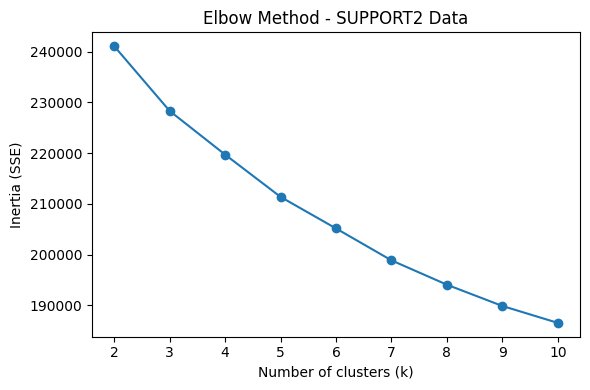

In [21]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

K = range(2, 11)      # k = 2 to 10
inertias_sup = []

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sup_scale)                 # uses Euclidean distance
    inertias_sup.append(km.inertia_)    # SSE / inertia

plt.figure(figsize=(6,4))
plt.plot(K, inertias_sup, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method - SUPPORT2 Data")
plt.tight_layout()
plt.show()

k=2, silhouette=0.1438
k=3, silhouette=0.1172
k=4, silhouette=0.1091
k=5, silhouette=0.1120
k=6, silhouette=0.0802
k=7, silhouette=0.0772
k=8, silhouette=0.0675
k=9, silhouette=0.0736
k=10, silhouette=0.0667


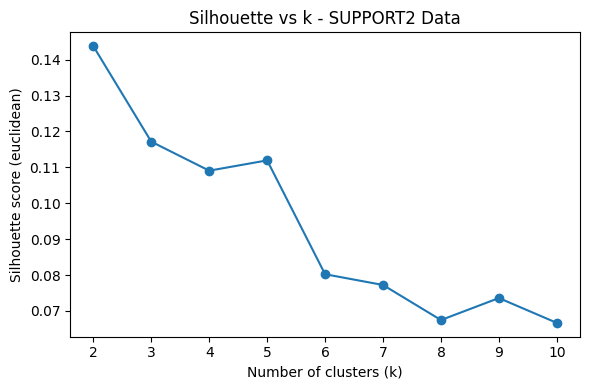

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

K = range(2, 11)
sil_scores_sup = []

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sup_scale)

    sil = silhouette_score(
        X_sup_scale,
        labels,
        metric='euclidean'   # no sample_size -> uses all 9105 rows
    )
    sil_scores_sup.append(sil)
    print(f"k={k}, silhouette={sil:.4f}")

plt.figure(figsize=(6,4))
plt.plot(K, sil_scores_sup, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score (euclidean)")
plt.title("Silhouette vs k - SUPPORT2 Data")
plt.tight_layout()
plt.show()

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

best_k_sup = 2  

km_best_sup = KMeans(n_clusters=best_k_sup, random_state=42, n_init=10)
labels_best_sup = km_best_sup.fit_predict(X_sup_scale)

for m in ['euclidean', 'manhattan', 'cosine']:
    score = silhouette_score(
        X_sup_scale,
        labels_best_sup,
        metric=m     # all rows, no sampling
    )
    print(f"{m}: silhouette = {score:.4f}")

euclidean: silhouette = 0.1438
manhattan: silhouette = 0.1684
cosine: silhouette = 0.1629


### SUPPORT2 Clustering Summary

For the SUPPORT2 dataset, K-Means clustering is used to explore whether patient-level clinical variables form separable groups. The silhouette scores and distance-metric comparison provide a practical view of cluster separation across the selected feature set.


## Overall Summary

Across the three healthcare datasets, this notebook uses K-Means clustering as an unsupervised modeling approach to compare possible cluster structures. The results show how feature scaling, cluster-count selection, and distance metrics influence clustering quality across different types of healthcare data.
